# Grid catalog continuation (point process on a grid)

End-to-end walkthrough of the **MAGNET pipeline: grid only (500 events, density 1e-5)** flow.

This notebook mirrors `simulate_catalog_continuation_grid` in `etas/simulation.py` and everything it calls from **your** modules (`forecast_intensity`, `data_utils`, `grid_simulation`, `utility_functions`). Those functions are copied here so each step is visible and easy to debug.

Only **upstream** `etas` modules are imported (`inversion`, `mc_b_est`, …). Configuration lives in the next cell — nothing is loaded from pipeline JSON files.

## Configuration

Values match `config/pipeline_single_source_repo_grid_default.json` and the VS Code launch **MAGNET pipeline: grid only (500 events, density 1e-5)**.

In [1]:
from pathlib import Path

REPO_ROOT = Path("/a/home/cc/students/csguests/neriberman/Repos/etas")

# --- time windows (UTC strings, same as pipeline overrides.set_times) ---
AUXILIARY_START = "1971-01-01 00:00:00"
TIMEWINDOW_START = "1981-01-01 00:00:00"
TIMEWINDOW_END = "2007-01-01 00:00:00"  # forecast start
TESTWINDOW_END = "2021-01-01 00:00:00"

# --- catalog & region ---
CATALOG_PATH = REPO_ROOT / "input_data" / "example_catalog.csv"
SHAPE_COORDS_PATH = REPO_ROOT / "input_data" / "california_shape.npy"

# --- inversion metadata (template invert_etas_config.json + forced completeness) ---
MC = 3.6
DELTA_M = 0.1
COPPERSMITH_MULTIPLIER = 100
THETA_0 = {
    "log10_mu": -5.8,
    "log10_k0": -2.6,
    "a": 1.8,
    "log10_c": -2.5,
    "omega": -0.02,
    "log10_tau": 3.5,
    "log10_d": -0.85,
    "gamma": 1.3,
    "rho": 0.66,
}
INVERSION_OUTPUT_DIR = REPO_ROOT / "outputs" / "notebook_grid_continuation" / "inversions"
FORCE_INVERSION = False  # set True to re-run inversion even if cached
STORE_PIJ = True
STORE_DISTANCES = True
GOF_THRESHOLD = 1.0  # pipeline uses 1 for debugging

# --- grid continuation (pipeline overrides.simulate_catalog_continuation) ---
FORECAST_DURATION_DAYS = 1000
CONTINUATION_MODE = "grid"
SEED = 1905
MAX_FORECAST_EVENTS = 500
GRID_POINT_DENSITY_KM2 = 5e-5
GRID_N_XY = (4, 4)  # used only when GRID_POINT_DENSITY_KM2 is None
MAGNITUDE_GENERATOR = "simulate_magnitudes"  # no MAGNET training in this launch config
KERNEL_VARIANT = "default"
PROGRESS_BAR = True

print("Configuration loaded:")
print(f"  catalog: {CATALOG_PATH}")
print(f"  shape:   {SHAPE_COORDS_PATH}")
print(f"  forecast: {TIMEWINDOW_END} + {FORECAST_DURATION_DAYS} d -> filter to {TESTWINDOW_END}")
print(f"  grid density: {GRID_POINT_DENSITY_KM2} pts/km², max events: {MAX_FORECAST_EVENTS}, seed: {SEED}")


Configuration loaded:
  catalog: /a/home/cc/students/csguests/neriberman/Repos/etas/input_data/example_catalog.csv
  shape:   /a/home/cc/students/csguests/neriberman/Repos/etas/input_data/california_shape.npy
  forecast: 2007-01-01 00:00:00 + 1000 d -> filter to 2021-01-01 00:00:00
  grid density: 5e-05 pts/km², max events: 500, seed: 1905


## Imports (upstream `etas` only)

In [2]:
import datetime as dt
import hashlib
import json
import logging
import os
import pprint

# Must run before pyplot so figures embed in the notebook (Cursor / VS Code / Jupyter).
%matplotlib inline

import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.path as mpltPath
from IPython.display import display
import numpy as np
import pandas as pd
import tqdm
from scipy import integrate, optimize
from scipy import special
from scipy.optimize import root_scalar
from scipy.integrate import quad
from shapely.geometry import Point, Polygon, MultiPoint
from shapely.prepared import prep
from shapely.ops import voronoi_diagram, transform

from etas.inversion import ETASParameterCalculation, polygon_surface
from etas import mc_b_est

try:
    import pyproj
except ImportError:
    pyproj = None

pp = pprint.PrettyPrinter(indent=2, width=100, sort_dicts=True)


def print_params(title, **kwargs):
    """Lightweight substitute for utility_functions.log_etas_params (no file I/O)."""
    print(f"\n=== {title} ===")
    for key, value in kwargs.items():
        if isinstance(value, dict):
            print(f"  {key}:")
            pp.pprint(value)
        else:
            print(f"  {key}: {value!r}")


2026-06-01 11:08:32.778757: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-06-01 11:08:32.814211: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-06-01 11:08:32.814252: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-06-01 11:08:32.815487: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-06-01 11:08:32.821953: I tensorflow/core/platform/cpu_feature_guar

## Copied helpers — `utility_functions` (spatial geometry)

In [3]:
EARTH_RADIUS_KM = 6.3781e3


def _hav(theta):
    return np.square(np.sin(theta / 2))


def haversine_km(lat_rad_1, lat_rad_2, lon_rad_1, lon_rad_2, earth_radius=EARTH_RADIUS_KM):
    return (
        2
        * earth_radius
        * np.arcsin(
            np.sqrt(
                _hav(lat_rad_1 - lat_rad_2)
                + np.cos(lat_rad_1) * np.cos(lat_rad_2) * _hav(lon_rad_1 - lon_rad_2)
            )
        )
    )


def km_per_degree_at_latitude(lat_deg, earth_radius=EARTH_RADIUS_KM):
    lat_rad = np.radians(np.asarray(lat_deg, dtype=float))
    km_per_lat = haversine_km(
        lat_rad - np.radians(0.5), lat_rad + np.radians(0.5), 0.0, 0.0, earth_radius
    )
    km_per_lon = haversine_km(lat_rad, lat_rad, 0.0, np.radians(1.0), earth_radius)
    if np.ndim(km_per_lat) == 0:
        return float(km_per_lat), float(km_per_lon)
    return km_per_lat, km_per_lon


def spatial_distance_squared_km2(lat_deg, lon_deg, lat_k_deg, lon_k_deg, earth_radius=EARTH_RADIUS_KM):
    lat_rad = np.radians(np.asarray(lat_deg, dtype=float))
    lon_rad = np.radians(np.asarray(lon_deg, dtype=float))
    lat_k_rad = np.radians(float(lat_k_deg))
    lon_k_rad = np.radians(float(lon_k_deg))
    return np.square(haversine_km(lat_k_rad, lat_rad, lon_k_rad, lon_rad, earth_radius))


## Copied helpers — `forecast_intensity`

In [4]:
GRID_DEFAULT_PARAMS = {
    "mu": 1e-7,
    "beta": np.log(10),
    "alpha": 1.9,
    "gamma": 1.3,
    "c": 10 ** (-2.2),
    "p": 1,
    "D": 0.5,
    "q": 1.5,
    "m0": 1,
}
KERNEL_VARIANT_DEFAULT = "default"
THETA_LOG10_TO_LINEAR = ("log10_mu", "log10_k0", "log10_c", "log10_tau", "log10_d")


def force_inversion_on_default_params(inversion_params, default_params=GRID_DEFAULT_PARAMS):
    inv = dict(inversion_params or {})
    inv_keys = set(inv.keys())
    params = default_params.copy()
    params.update(inv)
    for log_key in THETA_LOG10_TO_LINEAR:
        if log_key not in inv_keys or inv.get(log_key) is None:
            continue
        linear = log_key.replace("log10_", "", 1)
        if linear not in inv_keys:
            params[linear] = 10.0 ** float(inv[log_key])
    if "omega" in inv_keys and inv.get("omega") is not None:
        params["omega"] = float(inv["omega"])
        if "p" not in inv_keys:
            params["p"] = params["omega"] + 1.0
    elif "p" in inv_keys and inv.get("p") is not None and "omega" not in inv_keys:
        params["p"] = float(inv["p"])
        params["omega"] = params["p"] - 1.0
    if "rho" in inv_keys and inv.get("rho") is not None:
        params["rho"] = float(inv["rho"])
        if "q" not in inv_keys:
            params["q"] = float(inv["rho"]) + 1.0
    elif "q" in inv_keys and inv.get("q") is not None:
        params["q"] = float(inv["q"])
        if "rho" not in inv_keys:
            params["rho"] = float(inv["q"]) - 1.0
    else:
        params["rho"] = float(params.get("q", default_params["q"])) - 1.0
    if "D" not in inv_keys and params.get("d") is not None:
        params["D"] = float(params["d"]) ** 0.5
    return params


def _make_kernels_default(params):
    def mu(x, y):
        return params["mu"]

    def kappa(m, A=None):
        if A is None:
            A = params.get("k0")
            if A is None and "log10_k0" in params:
                A = np.power(10.0, params["log10_k0"])
            if A is None:
                A = 1.0
        a_eff = params.get("a", params.get("alpha", 0.0))
        return A * np.exp(a_eff * (m - params["m0"]))

    def g(t):
        t_arr = np.asarray(t, dtype=float)
        safe = np.maximum(t_arr, 0.0)
        val = np.exp(-safe / params["tau"]) / (safe + params["c"]) ** (1 + params["omega"])
        out = np.where(t_arr > 0, val, 0.0)
        if np.isscalar(t) or (hasattr(t, "shape") and t.shape == ()):
            return float(out)
        return out

    def G(t):
        return (
            (-np.exp(params["c"]/params["tau"]) * params["tau"]**(-params["omega"])
             ) * special.gammainc(-params["omega"], (params["c"] + t) / params["tau"])
        )

    def r(x, y, m):
        return (
            x**2 + y**2 + params["d"] * np.exp(params["gamma"] * (m - params["m0"]))
        ) ** (-(1 + params["rho"]))

    # def r(dist_sq_km2, m):
    #     return (
    #         dist_sq_km2 + params["d"] * np.exp(params["gamma"] * (m - params["m0"]))
    #     ) ** (-(1 + params["rho"]))

    def summand(dist_sq_km2, m, t):
        return kappa(m) * r(dist_sq_km2, m) * g(t)

    return {"mu": mu, "kappa": kappa, "g": g, "G": G, "f": r, "summand": summand}


def make_kernels(params=None, variant=KERNEL_VARIANT_DEFAULT):
    if params is None:
        params = GRID_DEFAULT_PARAMS.copy()
    v = variant.strip().lower() if isinstance(variant, str) else str(variant)
    if v == KERNEL_VARIANT_DEFAULT:
        return _make_kernels_default(params)
    raise ValueError(f"Unknown kernel variant {variant!r}")




def rate_at_t_all_grid(t_days, lat_flat, lon_flat, h_lat, h_lon, h_m, h_t_days, kernels=None):
    if kernels is None:
        kernels = make_kernels()
    kappa_fn = kernels["kappa"]
    g_fn = kernels["g"]
    f_fn = kernels["f"]
    mu_fn = kernels["mu"]
    n_grid = len(lat_flat)
    local_intensity = np.zeros(n_grid)
    for k in range(len(h_lat)):
        lat_k, lon_k, m_k, t_k_days = h_lat[k], h_lon[k], h_m[k], h_t_days[k]
        dt_days = t_days - t_k_days
        if dt_days <= 0:
            continue
        dist_sq = spatial_distance_squared_km2(lat_flat, lon_flat, lat_k, lon_k)
        local_intensity += kappa_fn(m_k) * f_fn(dist_sq, m_k) * g_fn(dt_days)
    mu_val = mu_fn(lat_flat[0], lon_flat[0])
    return mu_val + local_intensity


## Copied helpers — `data_utils`

In [5]:
def to_seconds(t):
    if hasattr(t, "timestamp"):
        return t.timestamp()
    return pd.Timestamp(t).timestamp()


def get_fallback_projection(lon, lat):
    if pyproj is None:
        raise ImportError("pyproj is required for get_fallback_projection")
    utm_crs_list = pyproj.database.query_utm_crs_info(
        datum_name="WGS 84",
        area_of_interest=pyproj.aoi.AreaOfInterest(
            west_lon_degree=float(lon),
            south_lat_degree=float(lat),
            east_lon_degree=float(lon) + 1e-5,
            north_lat_degree=float(lat) + 1e-5,
        ),
    )
    return pyproj.Proj(f"EPSG:{utm_crs_list[0].code}")


def latlon_rectangular_grid_in_polygon(
    polygon,
    grid_point_density_km2,
    *,
    earth_radius=EARTH_RADIUS_KM,
    rtol=0.05,
    max_iterations=40,
):
    if grid_point_density_km2 <= 0:
        raise ValueError("grid_point_density_km2 must be positive")
    area_km2 = float(polygon_surface(polygon))
    target_n = max(1, int(round(area_km2 * grid_point_density_km2)))
    min_lat, min_lon, max_lat, max_lon = polygon.bounds
    lat_c = 0.5 * (min_lat + max_lat)
    km_per_lat, km_per_lon = km_per_degree_at_latitude(lat_c, earth_radius)
    prep_poly = prep(polygon)
    spacing_km = float(np.sqrt(area_km2 / target_n))
    lat_flat = lon_flat = np.empty(0)
    n_lat = n_lon = 0
    for _ in range(max_iterations):
        spacing_lat = spacing_km / km_per_lat
        spacing_lon = spacing_km / km_per_lon
        n_lat = max(2, int(np.ceil((max_lat - min_lat) / spacing_lat)) + 1)
        n_lon = max(2, int(np.ceil((max_lon - min_lon) / spacing_lon)) + 1)
        lats = np.linspace(min_lat, max_lat, n_lat)
        lons = np.linspace(min_lon, max_lon, n_lon)
        lat_mesh, lon_mesh = np.meshgrid(lats, lons)
        lat_cand = lat_mesh.ravel()
        lon_cand = lon_mesh.ravel()
        inside = np.fromiter(
            (prep_poly.contains(Point(lat, lon)) for lat, lon in zip(lat_cand, lon_cand)),
            dtype=bool,
            count=lat_cand.size,
        )
        n_inside = int(inside.sum())
        if n_inside == 0:
            spacing_km *= 0.5
            continue
        lat_flat = lat_cand[inside]
        lon_flat = lon_cand[inside]
        if abs(n_inside - target_n) / target_n <= rtol:
            break
        spacing_km *= np.sqrt(n_inside / target_n)
    if lat_flat.size == 0:
        raise RuntimeError("Could not place any grid nodes inside the polygon")
    info = {
        "area_km2": area_km2,
        "target_n": target_n,
        "n_points": int(lat_flat.size),
        "spacing_km": spacing_km,
        "grid_n_xy": (n_lat, n_lon),
        "grid_point_density_km2": float(grid_point_density_km2),
    }
    return lat_flat, lon_flat, info


def estimate_area_km2_from_latlon_grid(lat_flat, lon_flat, earth_radius=EARTH_RADIUS_KM):
    lat_flat = np.asarray(lat_flat, dtype=float)
    lon_flat = np.asarray(lon_flat, dtype=float)
    unique_lat = np.unique(lat_flat)
    unique_lon = np.unique(lon_flat)
    if len(unique_lat) > 1 and len(unique_lon) > 1:
        dlat = float(np.mean(np.diff(np.sort(unique_lat))))
        dlon = float(np.mean(np.diff(np.sort(unique_lon))))
        mean_lat = float(np.mean(lat_flat))
        km_per_lat, km_per_lon = km_per_degree_at_latitude(mean_lat, earth_radius)
        cell_km2 = (dlat * km_per_lat) * (dlon * km_per_lon)
        return cell_km2 * len(lat_flat)
    km_per_lat, km_per_lon = km_per_degree_at_latitude(float(np.mean(lat_flat)), earth_radius)
    span_lat = float(lat_flat.max() - lat_flat.min())
    span_lon = float(lon_flat.max() - lon_flat.min())
    return max(span_lat * km_per_lat * span_lon * km_per_lon, 1e-12)


## Copied helpers — `grid_simulation.run_etas_per_grid_point_inversion`

Ogata-style compensator inversion on a spatial grid (same as production). Debug JSONL / event trace logging removed.

In [6]:
def _swap_xy(x, y):
    return y, x

def get_ordered_voronoi_cells(polygon_latlon, lat_flat, lon_flat):
    # Swap bounding polygon to standard (lon, lat)
    polygon_lonlat = transform(_swap_xy, polygon_latlon)
    
    # Create ordered points
    points = [Point(lon, lat) for lon, lat in zip(lon_flat, lat_flat)]
    
    # Generate raw Voronoi diagram
    vd = voronoi_diagram(MultiPoint(points), envelope=polygon_lonlat)
    raw_cells = list(vd.geoms)
    
    # Use spatial join to map the unordered cells back to the exact order of input points
    points_gdf = gpd.GeoDataFrame(geometry=points)
    cells_gdf = gpd.GeoDataFrame(geometry=raw_cells)
    
    matched = points_gdf.sjoin(cells_gdf, how="left", predicate="intersects")
    matched = matched[~matched.index.duplicated(keep='first')]
    
    ordered_clipped_cells = []
    
    for idx in matched['index_right'].values:
        if np.isnan(idx):
            # Point is completely orphaned/outside
            ordered_clipped_cells.append(Polygon()) 
        else:
            # Extract matched cell and clip it to the overarching polygon boundary
            cell = raw_cells[int(idx)]
            clipped_cell = cell.intersection(polygon_lonlat)
            ordered_clipped_cells.append(clipped_cell)
            
    return ordered_clipped_cells


def monte_carlo_polygon_integral(polygon, r_func, x_i, y_i, m_i, num_points=10000):
    # 1. Get bounding box
    min_lon, min_lat, max_lon, max_lat = polygon.bounds
    
    # 2. Generate random points within the bounding box
    x_rand = np.random.uniform(min_lon, max_lon, num_points)
    y_rand = np.random.uniform(min_lat, max_lat, num_points)
    points = np.column_stack((x_rand, y_rand))
    
    # 3. Fast vectorized check for points inside the polygon using matplotlib
    # Extract exterior coordinates of the Shapely polygon
    poly_path = mpltPath.Path(list(polygon.exterior.coords))
    inside_mask = poly_path.contains_points(points)
    
    # Filter points inside
    x_inside = x_rand[inside_mask]
    y_inside = y_rand[inside_mask]
    
    if len(x_inside) == 0:
        return 0.0
        
    # 4. Evaluate the function on the valid points
    # This is entirely vectorized and can be pushed to a GPU if using PyTorch/CuPy
    f_values = r_func(x_inside - x_i, y_inside - y_i, m_i)
    
    # 5. Calculate integral: (Average value of f) * (Area of the bounding box) * (ratio of points inside)
    # Equivalently: Average of f inside * Area of Polygon
    mean_f = np.mean(f_values)
    
    return mean_f * polygon.area


def calculate_areas_km2(polygons):
    geod = pyproj.Geod(ellps="WGS84")
    areas = []
    
    for poly in polygons:
        if poly.is_empty:
            # Handle orphaned points that returned an empty Polygon()
            areas.append(0.0)
        else:
            # geometry_area_perimeter calculates exact geodesic area on the ellipsoid
            area_m2, _ = geod.geometry_area_perimeter(poly)
            areas.append(abs(area_m2) / 1e6)
            
    return areas


def omori_for_all_previous_events(current_time_days, working_history, kernels):
    t_i = working_history["time"].values / SECONDS_PER_DAY
    return kernels["g"](current_time_days - t_i).ravel()





In [7]:
SECONDS_PER_DAY = 86400.0


def run_etas_per_grid_point_inversion(
    history,
    start_forecast,
    end_forecast,
    lat_flat,
    lon_flat,
    params=None,
    *,
    in_place=False,
    projection=None,
    progress_bar=True,
    seed=None,
    kernel_variant=KERNEL_VARIANT_DEFAULT,
    max_forecast_events=None,
    area_km2=None,
    polygon=None,
):
    if params is None:
        params = GRID_DEFAULT_PARAMS.copy()
    print_params(
        "run_etas_per_grid_point_inversion",
        params=params,
        start_forecast=float(start_forecast),
        end_forecast=float(end_forecast),
        n_grid_points=int(len(lat_flat)),
        max_forecast_events=max_forecast_events,
        kernel_variant=kernel_variant,
        area_km2=area_km2,
    )
    if seed is not None:
        np.random.seed(seed)
    kernels = make_kernels(params, variant=kernel_variant)
    working_history = history.copy() if not in_place else history
    if not isinstance(working_history, pd.DataFrame):
        working_history = pd.DataFrame(working_history)
    history_original = working_history.copy()
    n_past = len(history_original)
    n_grid = len(lat_flat)
    t = float(start_forecast)
    events_generated = 0
    total_duration = end_forecast - start_forecast
    pbar = tqdm.tqdm(total=total_duration, desc="Simulation", unit="sim s") if progress_bar else None

    mu_density = float(kernels["mu"](lat_flat[0], lon_flat[0]))
    if area_km2 is None:
        area_km2 = estimate_area_km2_from_latlon_grid(lat_flat, lon_flat)
        print(f"  area_km2 estimated from grid layout: {area_km2:.4g}")
    area_km2 = float(area_km2)
    cell_area_km2 = area_km2 / n_grid
    mu_background = mu_density * area_km2
    print(
        f"  mu_density={mu_density:.4g} events/day/km², mu_background={mu_background:.4g} events/day, "
        f"  cell_area_km2={cell_area_km2:.4g}"
    )

    # prepare sum of historical events
    ordered_cells = get_ordered_voronoi_cells(polygon, lat_flat, lon_flat)
    r_spatial_integral = np.empty((len(lat_flat), len(working_history)))
    p_m = np.empty((len(lat_flat), len(working_history)))
    for j in range(len(lat_flat)):
        for i in range(len(working_history)):
            r_spatial_integral[j, i] = monte_carlo_polygon_integral(ordered_cells[j], kernels["f"], lon_flat[j], lat_flat[j], working_history["magnitude"].iloc[i])
            p_m[j, i] = kernels["kappa"](working_history["magnitude"].iloc[i])
    spatio_mag_part = r_spatial_integral * p_m
            
    areas = calculate_areas_km2(ordered_cells)

    # spatial_weights = []
    # for k in range(len(working_history)):
    #     dist_sq = spatial_distance_squared_km2(
    #         lat_flat, lon_flat, working_history["latitude"].iloc[k], working_history["longitude"].iloc[k]
    #     )
    #     m_k = working_history["magnitude"].iloc[k]
    #     spatial_weights.append(kernels["kappa"](m_k) * np.sum(kernels["f"](dist_sq, m_k)))
    # spatial_weights = np.asarray(spatial_weights, dtype=float)

    magnitude_generator = mc_b_est.simulate_magnitudes
    # Pre-calculate constants
    q_derivative = kernels["g"]
    G_integrated = kernels["G"]
    areas_array = np.array(areas)
    mu_per_cell = mu_density * areas_array
    
    step_index = 0
    while t < end_forecast:
        step_index += 1
        t_days = t / SECONDS_PER_DAY
        h_t_days = working_history["time"].values / SECONDS_PER_DAY

        # Array to store the simulated next event time for every single cell
        t_next_cells = np.full(n_grid, np.inf)
        
        # Pre-compute current Omori kernel values since they are the same for all cells at time t
        w_start = t_days - h_t_days
        current_q_vals = q_derivative(w_start)
        G_start = G_integrated(w_start)

        # 1. Solve the exact compensator equation for EVERY cell independently
        for j in range(n_grid):
            target_j = -np.log(np.random.uniform(0, 1))
            mu_j = mu_per_cell[j]
            weights_j = spatio_mag_part[j, :]
            
            def F_j(t_prime_days):
                term1 = mu_j * (t_prime_days - t_days)
                w_end = t_prime_days - h_t_days
                integral_diffs = G_integrated(w_end) - G_start
                term2 = np.sum(weights_j * integral_diffs)
                return term1 + term2 - target_j

            def F_prime_j(t_prime_days):
                w_prime = t_prime_days - h_t_days
                q_vals = q_derivative(w_prime)
                return mu_j + np.sum(weights_j * q_vals)

            # F_j(t_days) is exactly -target_j (which is strictly negative).
            # We calculate a safe upper bound where F_j(t_upper) > 0.
            # The background rate mu_j guarantees the integral grows by at least mu_j * dt.
            if mu_j > 1e-12:
                t_upper = t_days + (target_j / mu_j)
            else:
                t_upper = t_days + 1000.0 # arbitrary forward step if background is effectively 0
            
            # Safely expand the bracket if the target hasn't been reached yet
            max_expansions = 20
            expansions = 0
            while F_j(t_upper) < 0 and expansions < max_expansions:
                t_upper += (t_upper - t_days) * 2
                expansions += 1
                
            if F_j(t_upper) < 0:
                # The total future integral of this cell will never reach the target U.
                # This means the cell will never fire again in infinite time.
                t_next_cells[j] = np.inf
                continue
                
            # Brent's method is unconditionally stable within a valid bracket.
            # We relax xtol slightly to 1e-4 days (about 8.6 seconds) to speed up the POC.
            sol = root_scalar(F_j, bracket=[t_days, t_upper], method='brentq', xtol=1e-4)
            
            if not sol.converged:
                # Absolute fallback if it somehow fails, though mathematically Brentq shouldn't fail
                raise RuntimeError(f"Brentq failed for cell {j} at step {step_index}.")
                
            t_next_cells[j] = sol.root
        # 2. The true next event is the one that occurs strictly first in time
        chosen_j = np.argmin(t_next_cells)
        t_next_days = t_next_cells[chosen_j]
        t_next_sec = t_next_days * SECONDS_PER_DAY

        # 3. Check if we exceeded the simulation window
        if t_next_sec > end_forecast:
            if pbar:
                pbar.update(end_forecast - t)
                pbar.set_postfix_str(
                    f"t={end_forecast / SECONDS_PER_DAY:.3f} d | window 100.0%"
                )
            break

        # 4. Extract parameters for the winning event
        lon_next = lon_flat[chosen_j]
        lat_next = lat_flat[chosen_j]
        
        # Assign magnitude to event with magnitude_generator
        m_next = magnitude_generator(1, params["beta"], params["m0"], m_max=None)[0]

        # 5. Update history and spatial weight matrices
        t_prev = t
        t = t_next_sec
        
        # -- Append to working_history
        new_event = pd.DataFrame(
            {"time": [t_next_sec], "latitude": [lat_next], "longitude": [lon_next], "magnitude": [m_next]}
        )
        working_history = pd.concat([working_history, new_event], ignore_index=True)
        
        # -- Update spatio_mag_part --
        # Evaluate monte_carlo_polygon_integral against ALL j cells for this single new event
        new_weights = np.empty((n_grid, 1))
        for j in range(n_grid):
            r_val = monte_carlo_polygon_integral(ordered_cells[j], kernels["f"], lon_next, lat_next, m_next)
            p_val = kernels["kappa"](m_next)
            new_weights[j, 0] = r_val * p_val
        spatio_mag_part = np.hstack((spatio_mag_part, new_weights))

        events_generated += 1
        if pbar:
            pbar.update(t - t_prev)
            pct = (
                100.0 * (t - start_forecast) / total_duration
                if total_duration > 0
                else 100.0
            )
            pbar.set_postfix_str(
                f"t={t / SECONDS_PER_DAY:.3f} d | window {pct:.1f}%"
            )
        if max_forecast_events is not None and max_forecast_events > 0:
            if events_generated >= max_forecast_events:
                if pbar:
                    pbar.update(max(0.0, end_forecast - t))
                break




    # step_index = 0
    # while t < end_forecast:
    #     step_index += 1
    #     h_t_days = working_history["time"].values / SECONDS_PER_DAY
    #     t_days = t / SECONDS_PER_DAY

    #     omori_weights = omori_for_all_previous_events(t_days, working_history, kernels)
    #     omori_weights = omori_weights[None, :]
    #     total_rate_per_cell = mu_density*areas + (spatio_mag_part * omori_weights).sum(axis=1)

    #     # TODO: I got the rate per cell (i.e. per grid point). Now I need to solve using the inverse sampling for the expected time of the next event in each grid pointand continue from there.

    #     def total_rate(v_days):
    #         dt = v_days - h_t_days
    #         valid = dt > 0
    #         triggered = np.sum(spatial_weights[valid] * kernels["g"](dt[valid]))
    #         return mu_background + cell_area_km2 * triggered

    #     u = float(np.random.uniform(0.0, 1.0))
    #     d_comp = -np.log(u)
    #     current_rate = float(total_rate(t_days))

    #     def objective(t_prime_days):
    #         area, _ = integrate.quad(total_rate, t_days, t_prime_days, limit=200)
    #         return area - d_comp

    #     guess_step_days = d_comp / current_rate if current_rate > 0 else 0.1
    #     res = optimize.root_scalar(
    #         objective,
    #         x0=t_days + guess_step_days,
    #         fprime=total_rate,
    #         method="newton",
    #         maxiter=50,
    #     )
    #     t_star = float(res.root * SECONDS_PER_DAY)
    #     accepted = t_star < end_forecast

    #     if step_index <= 3 or step_index % 50 == 0:
    #         print(
    #             f"  step {step_index}: t={t/SECONDS_PER_DAY:.4f} d, rate={current_rate:.4g}, "
    #             f"d_comp={d_comp:.4g}, t*={t_star/SECONDS_PER_DAY:.4f} d, accepted={accepted}"
    #         )

    #     if not accepted:
    #         if pbar:
    #             pbar.update(end_forecast - t)
    #         break

    #     rates_at_loc = rate_at_t_all_grid(
    #         t_star / SECONDS_PER_DAY,
    #         lat_flat,
    #         lon_flat,
    #         working_history["latitude"].values,
    #         working_history["longitude"].values,
    #         working_history["magnitude"].values,
    #         h_t_days,
    #         kernels=kernels,
    #     )
    #     rates_at_loc = rates_at_loc * cell_area_km2
    #     rates_at_loc = np.nan_to_num(rates_at_loc, nan=0.0, posinf=0.0, neginf=0.0)
    #     rates_at_loc = np.maximum(rates_at_loc, 0.0)
    #     total_spatial = float(np.sum(rates_at_loc))
    #     if total_spatial <= 0:
    #         min_idx = int(np.random.randint(n_grid))
    #     else:
    #         min_idx = int(np.random.choice(n_grid, p=rates_at_loc / total_spatial))
    #     new_lat = lat_flat[min_idx]
    #     new_lon = lon_flat[min_idx]
    #     b_value = params.get("b", 1.0)
    #     m0 = params.get("m0", params.get("m_ref", 2.0))
    #     new_m = float(np.random.exponential(1.0 / (b_value * np.log(10))) + m0)

    #     new_event = pd.DataFrame(
    #         {"time": [t_star], "latitude": [new_lat], "longitude": [new_lon], "magnitude": [new_m]}
    #     )
    #     if projection is not None:
    #         x_utm, y_utm = projection(float(new_lon), float(new_lat), inverse=False)
    #         new_event["x_utm"] = x_utm
    #         new_event["y_utm"] = y_utm
    #     working_history = pd.concat([working_history, new_event], ignore_index=True)
    #     new_dist_sq = spatial_distance_squared_km2(lat_flat, lon_flat, new_lat, new_lon)
    #     spatial_weights = np.append(
    #         spatial_weights,
    #         kernels["kappa"](new_m) * np.sum(kernels["f"](new_dist_sq, new_m)),
    #     )
        # if pbar:
        #     pbar.update(t_star - t)
        # t = t_star
        # events_generated += 1
        # if max_forecast_events is not None and max_forecast_events > 0:
        #     if events_generated >= max_forecast_events:
        #         if pbar:
        #             pbar.update(max(0.0, end_forecast - t_star))
        #         break

    if pbar:
        pbar.close()
    print(f"  generated {events_generated} forecast events in {step_index} inversion steps")
    forecast_only = working_history.iloc[n_past:].copy()
    if forecast_only.empty:
        return history_original.copy()
    return pd.concat([history_original, forecast_only], ignore_index=True)


## Copied — `simulate_catalog_continuation_grid` (`etas/simulation.py`)

In [8]:
def simulate_catalog_continuation_grid(
    auxiliary_catalog,
    auxiliary_end,
    simulation_end,
    polygon,
    parameters,
    mc,
    beta_main,
    *,
    grid_n_xy=(4, 4),
    grid_point_density_km2=None,
    grid_params=None,
    projection=None,
    seed=None,
    filter_polygon=True,
    progress_bar=True,
    kernel_variant=KERNEL_VARIANT_DEFAULT,
    max_forecast_events=None,
):
    if grid_params is None:
        grid_params = GRID_DEFAULT_PARAMS.copy()
        grid_params["beta"] = beta_main if np.isscalar(beta_main) else np.log(10)
        if parameters and "log10_mu" in parameters:
            grid_params["mu"] = np.power(10, parameters["log10_mu"])
    else:
        grid_params = dict(grid_params)
    if mc is not None:
        grid_params["m0"] = float(mc)

    print_params(
        "simulate_catalog_continuation_grid",
        parameters=parameters,
        grid_params=grid_params,
        grid_n_xy=grid_n_xy,
        grid_point_density_km2=grid_point_density_km2,
        max_forecast_events=max_forecast_events,
        mc=float(mc) if mc is not None else None,
        seed=seed,
    )

    start_sec = to_seconds(auxiliary_end)
    end_sec = to_seconds(simulation_end)
    print(f"  forecast window (seconds): {start_sec} -> {end_sec} ({(end_sec - start_sec) / SECONDS_PER_DAY:.1f} days)")

    mask = auxiliary_catalog["time"] < auxiliary_end
    history = auxiliary_catalog.loc[mask].copy()
    if len(history) == 0:
        history = pd.DataFrame(columns=["time", "magnitude", "latitude", "longitude", "x_utm", "y_utm"])
    print(f"  history events before forecast start: {len(history)}")

    # if projection is None and pyproj is not None:
    #     centroid = polygon.centroid
    #     projection = get_fallback_projection(lon=centroid.y, lat=centroid.x)
    #     print(f"  using fallback UTM projection at centroid ({centroid.x:.3f}, {centroid.y:.3f})")

    # if "latitude" not in history.columns or "longitude" not in history.columns:
    #     if len(history) > 0 and "x_utm" in history.columns and projection is not None:
    #         lonlat = np.array([
    #             projection(history["x_utm"].values[i], history["y_utm"].values[i], inverse=True)
    #             for i in range(len(history))
    #         ])
    #         history["longitude"] = lonlat[:, 0]
    #         history["latitude"] = lonlat[:, 1]
    #     elif len(history) > 0:
    #         raise ValueError("auxiliary_catalog has no latitude/longitude and no projection")

    # if "x_utm" not in history.columns and "latitude" in history.columns and len(history) > 0:
    #     if projection is not None:
    #         xy = np.array([
    #             projection(history["longitude"].values[i], history["latitude"].values[i], inverse=False)
    #             for i in range(len(history))
    #         ])
    #         history["x_utm"] = xy[:, 0]
    #         history["y_utm"] = xy[:, 1]

    if "time" in history.columns:
        history = history.copy()
        history["time"] = history["time"].apply(to_seconds)

    min_lat, min_lon, max_lat, max_lon = polygon.bounds
    if len(history) > 0 and "latitude" in history.columns:
        lat_min = min(min_lat, history["latitude"].min())
        lat_max = max(max_lat, history["latitude"].max())
        lon_min = min(min_lon, history["longitude"].min())
        lon_max = max(max_lon, history["longitude"].max())
    else:
        lat_min, lon_min, lat_max, lon_max = min_lat, min_lon, max_lat, max_lon

    if grid_point_density_km2 is not None:
        lat_flat, lon_flat, grid_info = latlon_rectangular_grid_in_polygon(
            polygon, grid_point_density_km2
        )
        print(
            f"  grid from density {grid_point_density_km2:.4g} pts/km²: "
            f"{grid_info['n_points']} nodes (target {grid_info['target_n']}, "
            f"spacing {grid_info['spacing_km']:.3f} km, rectangle {grid_info['grid_n_xy']})"
        )
    else:
        n_x, n_y = grid_n_xy
        lat_1d = np.linspace(lat_min, lat_max, n_x)
        lon_1d = np.linspace(lon_min, lon_max, n_y)
        Lat, Lon = np.meshgrid(lat_1d, lon_1d)
        lat_flat = Lat.flatten()
        lon_flat = Lon.flatten()
        grid_info = {"n_points": len(lat_flat), "grid_n_xy": grid_n_xy}
        print(f"  fixed grid {grid_n_xy}: {len(lat_flat)} nodes")

    for col in ["time", "magnitude", "latitude", "longitude"]:
        if col not in history.columns and len(history) > 0:
            history[col] = np.nan
    if len(history) == 0:
        history = pd.DataFrame({"time": [], "magnitude": [], "latitude": [], "longitude": []})

    area_km2 = polygon_surface(polygon)
    print(f"  polygon area (inversion): {area_km2:.4g} km²")

    history = run_etas_per_grid_point_inversion(
        history,
        start_sec,
        end_sec,
        lat_flat,
        lon_flat,
        params=grid_params,
        in_place=False,
        projection=projection,
        progress_bar=progress_bar,
        seed=seed,
        kernel_variant=kernel_variant,
        max_forecast_events=max_forecast_events,
        area_km2=area_km2,
        polygon=polygon,
    )

    new_mask = history["time"] >= start_sec
    new_ev = history.loc[new_mask].copy()
    new_ev["time"] = pd.to_datetime(new_ev["time"], unit="s")
    if projection is not None and len(new_ev) > 0 and "x_utm" not in new_ev.columns:
        xy = np.array([
            projection(new_ev["longitude"].values[i], new_ev["latitude"].values[i], inverse=False)
            for i in range(len(new_ev))
        ])
        new_ev["x_utm"] = xy[:, 0]
        new_ev["y_utm"] = xy[:, 1]

    new_ev["generation"] = 0
    new_ev["parent"] = 0
    new_ev["is_background"] = True
    base_idx = auxiliary_catalog.index.max()
    if pd.isna(base_idx):
        base_idx = 0
    new_ev["evt_id"] = np.arange(len(new_ev)) + base_idx + 1
    keep_cols = [
        "latitude", "longitude", "time", "magnitude",
        "generation", "parent", "is_background", "evt_id",
    ]
    for c in keep_cols:
        if c not in new_ev.columns:
            new_ev[c] = np.nan
    new_ev = new_ev[keep_cols]

    catalog = pd.concat([auxiliary_catalog, new_ev], sort=True, ignore_index=True)
    catalog = catalog.sort_values(by="time").reset_index(drop=True)

    if filter_polygon:
        catalog = gpd.GeoDataFrame(
            catalog, geometry=gpd.points_from_xy(catalog.latitude, catalog.longitude)
        )
        catalog = catalog[catalog.intersects(polygon)]
        return catalog.drop("geometry", axis=1)
    return catalog


## Step 1 — ETAS inversion (upstream)

Same inputs as the pipeline's temp `invert_etas.json`. Results are cached under `INVERSION_OUTPUT_DIR`.

In [9]:
def inversion_id_from_config(cfg, *, store_pij=False, store_distances=False):
    key_params = {
        "fn_catalog": str(cfg.get("fn_catalog", "")),
        "auxiliary_start": str(cfg.get("auxiliary_start", "")),
        "timewindow_start": str(cfg.get("timewindow_start", "")),
        "timewindow_end": str(cfg.get("timewindow_end", "")),
        "testwindow_end": str(cfg.get("testwindow_end", "")),
        "mc": str(cfg.get("mc")),
        "delta_m": str(cfg.get("delta_m")),
        "store_pij": str(store_pij),
        "store_distances": str(store_distances),
        "shape_coords": str(cfg.get("shape_coords")),
    }
    return hashlib.sha1(json.dumps(key_params, sort_keys=True).encode()).hexdigest()[:16]


inversion_config = {
    "fn_catalog": str(CATALOG_PATH),
    "data_path": str(INVERSION_OUTPUT_DIR) + os.sep,
    "auxiliary_start": AUXILIARY_START,
    "timewindow_start": TIMEWINDOW_START,
    "timewindow_end": TIMEWINDOW_END,
    "testwindow_end": TESTWINDOW_END,
    "theta_0": THETA_0,
    "mc": MC,
    "delta_m": DELTA_M,
    "coppersmith_multiplier": COPPERSMITH_MULTIPLIER,
    "shape_coords": str(SHAPE_COORDS_PATH),
}

inv_id = inversion_id_from_config(
    inversion_config, store_pij=STORE_PIJ, store_distances=STORE_DISTANCES
)
inv_run_dir = INVERSION_OUTPUT_DIR / f"inv_{inv_id}"
params_json = inv_run_dir / f"parameters_{inv_id}.json"

print_params("inversion_config", **inversion_config)
print(f"  inversion id: {inv_id}")
print(f"  expected parameters file: {params_json}")

if params_json.exists() and not FORCE_INVERSION:
    print("Using cached inversion parameters.")
else:
    print("Running ETAS inversion (this may take a while)…")
    inversion_config["id"] = inv_id
    inv_run_dir.mkdir(parents=True, exist_ok=True)
    INVERSION_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
    calc = ETASParameterCalculation(inversion_config)
    calc.prepare()
    calc.invert(gof_threshold=GOF_THRESHOLD)
    calc.store_results(str(inv_run_dir) + os.sep, store_pij=STORE_PIJ, store_distances=STORE_DISTANCES)
    print(f"Inversion stored in {inv_run_dir}")

with open(params_json) as f:
    inversion_output = json.load(f)
etas_inversion = ETASParameterCalculation.load_calculation(inversion_output)
print_params("fitted theta", parameters=etas_inversion.theta)



=== inversion_config ===
  fn_catalog: '/a/home/cc/students/csguests/neriberman/Repos/etas/input_data/example_catalog.csv'
  data_path: '/a/home/cc/students/csguests/neriberman/Repos/etas/outputs/notebook_grid_continuation/inversions/'
  auxiliary_start: '1971-01-01 00:00:00'
  timewindow_start: '1981-01-01 00:00:00'
  timewindow_end: '2007-01-01 00:00:00'
  testwindow_end: '2021-01-01 00:00:00'
  theta_0:
{ 'a': 1.8,
  'gamma': 1.3,
  'log10_c': -2.5,
  'log10_d': -0.85,
  'log10_k0': -2.6,
  'log10_mu': -5.8,
  'log10_tau': 3.5,
  'omega': -0.02,
  'rho': 0.66}
  mc: 3.6
  delta_m: 0.1
  coppersmith_multiplier: 100
  shape_coords: '/a/home/cc/students/csguests/neriberman/Repos/etas/input_data/california_shape.npy'
  inversion id: 98a6071a3d8a95d4
  expected parameters file: /a/home/cc/students/csguests/neriberman/Repos/etas/outputs/notebook_grid_continuation/inversions/inv_98a6071a3d8a95d4/parameters_98a6071a3d8a95d4.json
Using cached inversion parameters.
2026-06-01 11:08:34,907 - 

## Step 2 — Build auxiliary catalog & forecast window

Mirrors `ETASSimulation.prepare()` + the arguments passed to `simulate_catalog_continuation_grid` in `ETASSimulation.simulate`.

In [10]:
polygon = Polygon(etas_inversion.shape_coords)
forecast_start = etas_inversion.timewindow_end
forecast_end = forecast_start + dt.timedelta(days=FORECAST_DURATION_DAYS)

source_events = etas_inversion.source_events.copy()
if "xi_plus_1" not in source_events.columns:
    source_events["xi_plus_1"] = 1

auxiliary_catalog = pd.merge(
    source_events,
    etas_inversion.catalog[["latitude", "longitude", "time", "magnitude"]],
    left_index=True,
    right_index=True,
    how="left",
)

mc = etas_inversion.m_ref - etas_inversion.delta_m / 2
m_threshold = etas_inversion.m_ref

print_params(
    "simulation setup",
    forecast_start=str(forecast_start),
    forecast_end=str(forecast_end),
    forecast_duration_days=FORECAST_DURATION_DAYS,
    m_ref=etas_inversion.m_ref,
    mc=mc,
    m_threshold=m_threshold,
    beta=etas_inversion.beta,
    n_auxiliary_events=len(auxiliary_catalog),
    continuation_mode=CONTINUATION_MODE,
    magnitude_generator=MAGNITUDE_GENERATOR,
)



=== simulation setup ===
  forecast_start: '2007-01-01 00:00:00'
  forecast_end: '2009-09-27 00:00:00'
  forecast_duration_days: 1000
  m_ref: 3.6
  mc: 3.5500000000000003
  m_threshold: 3.6
  beta: 2.291304156139075
  n_auxiliary_events: 3303
  continuation_mode: 'grid'
  magnitude_generator: 'simulate_magnitudes'


## Step 3 — Build `grid_params` (pipeline `grid_params_from_inversion`)

In [11]:
grid_params = force_inversion_on_default_params(etas_inversion.theta or {})
grid_params["m0"] = mc
grid_params["beta"] = etas_inversion.beta

print_params("grid_params for grid simulator", grid_params=grid_params)

np.random.seed(SEED)
print(f"RNG seeded with {SEED}")



=== grid_params for grid simulator ===
  grid_params:
{ 'D': 0.6916103193081605,
  'a': 1.8147284901476872,
  'alpha': 1.9,
  'beta': 2.291304156139075,
  'c': 0.000772097348687239,
  'd': 0.47832483377353574,
  'gamma': 1.1908402144983095,
  'k0': 0.003552039279336742,
  'log10_c': -3.1123279388711307,
  'log10_d': -0.320277070746616,
  'log10_iota': None,
  'log10_k0': -2.449522240330126,
  'log10_mu': -7.33105975591647,
  'log10_tau': 3.6098916759499717,
  'm0': 3.5500000000000003,
  'mu': 4.66595175628844e-08,
  'omega': -0.0360643447488232,
  'p': 0.9639356552511767,
  'q': 1.6176230718737372,
  'rho': 0.6176230718737372,
  'tau': 4072.786795097897}
RNG seeded with 1905


## Step 4 — Run grid continuation

In [12]:
print("dbg this shit")
print("do it")

continuation = simulate_catalog_continuation_grid(
    auxiliary_catalog,
    forecast_start,
    forecast_end,
    polygon,
    etas_inversion.theta,
    mc=mc,
    beta_main=etas_inversion.beta,
    filter_polygon=False,  # same as ETASSimulation.simulate for grid mode
    grid_n_xy=GRID_N_XY,
    grid_point_density_km2=GRID_POINT_DENSITY_KM2,
    grid_params=grid_params,
    projection=None,
    seed=SEED,
    progress_bar=PROGRESS_BAR,
    kernel_variant=KERNEL_VARIANT,
    max_forecast_events=MAX_FORECAST_EVENTS,
)

# Post-filter like ETASSimulation.simulate (forecast window + magnitude cutoff)
simulated = continuation.query(
    "time >= @forecast_start and time <= @forecast_end and magnitude >= @m_threshold - @etas_inversion.delta_m / 2"
).copy()

print(f"\nFull continuation catalog: {len(continuation)} events")
print(f"Forecast-window simulated events (after magnitude filter): {len(simulated)}")
if len(simulated):
    display(simulated[["time", "latitude", "longitude", "magnitude"]].head(10))
    print(simulated[["time", "magnitude"]].describe())


dbg this shit


Value(False)
do it

=== simulate_catalog_continuation_grid ===
  parameters:
{ 'a': 1.8147284901476872,
  'gamma': 1.1908402144983095,
  'log10_c': -3.1123279388711307,
  'log10_d': -0.320277070746616,
  'log10_iota': None,
  'log10_k0': -2.449522240330126,
  'log10_mu': -7.33105975591647,
  'log10_tau': 3.6098916759499717,
  'omega': -0.0360643447488232,
  'rho': 0.6176230718737372}
  grid_params:
{ 'D': 0.6916103193081605,
  'a': 1.8147284901476872,
  'alpha': 1.9,
  'beta': 2.291304156139075,
  'c': 0.000772097348687239,
  'd': 0.47832483377353574,
  'gamma': 1.1908402144983095,
  'k0': 0.003552039279336742,
  'log10_c': -3.1123279388711307,
  'log10_d': -0.320277070746616,
  'log10_iota': None,
  'log10_k0': -2.449522240330126,
  'log10_mu': -7.33105975591647,
  'log10_tau': 3.6098916759499717,
  'm0': 3.5500000000000003,
  'mu': 4.66595175628844e-08,
  'omega': -0.0360643447488232,
  'p': 0.9639356552511767,
  'q': 1.6176230718737372,
  'rho': 0.6176230718737372,
  'tau': 4072.786

Simulation:   0%|          | 0/86400000.0 [00:00<?, ?sim s/s]

  mu_density=4.666e-08 events/day/km², mu_background=0.04478 events/day,   cell_area_km2=1.92e+04


Simulation: 100%|██████████| 86400000.0/86400000.0 [01:35<00:00, 907385.06sim s/s, t=14514.000 d | window 100.0%]        


  generated 22 forecast events in 23 inversion steps

Full continuation catalog: 3325 events
Forecast-window simulated events (after magnitude filter): 22


,time,latitude,longitude,magnitude
3303,2007-07-29 08:29:40.844490767,36.00,-114.077778,4.090658
3304,2007-09-18 12:38:05.043236494,41.00,-124.422222,3.748593
3305,2007-10-09 12:10:59.059595585,38.50,-118.511111,3.740857
3306,2007-12-22 00:49:39.735270023,32.25,-114.077778,3.700782
3307,2008-03-16 00:28:24.721373081,36.00,-118.511111,3.696109
3308,2008-04-14 16:58:25.035199642,34.75,-117.033333,3.574875
3309,2008-05-04 14:48:23.103588343,36.00,-118.511111,4.109352
3310,2008-06-04 19:41:45.935222149,36.00,-119.988889,4.030808
3311,2008-07-08 14:19:20.665966511,38.50,-122.944444,3.627233
3312,2008-07-09 18:16:45.060716152,32.25,-114.077778,3.919237


                                time  magnitude
count                             22  22.000000
mean   2008-09-08 13:55:43.723774464   4.038102
min    2007-07-29 08:29:40.844490767   3.571706
25%    2008-04-19 16:25:54.552296960   3.710801
50%    2008-09-08 21:42:02.946952448   4.020804
75%    2009-01-24 00:46:45.173434368   4.109252
max    2009-09-04 09:43:50.972161770   5.658177
std                              NaN   0.454608


## Step 5 — Catalog diagnostics plots

Magnitude–time, cumulative event counts (with `set_times` window resets), inter-event **Δt**, and magnitude-frequency histograms. **Original** = auxiliary catalog before forecast; **continuation** = post-filter forecast events (`simulated`).

/tmp/ipykernel_580929/4067549159.py:123: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


Catalog rows — original: 3303, continuation (forecast): 22


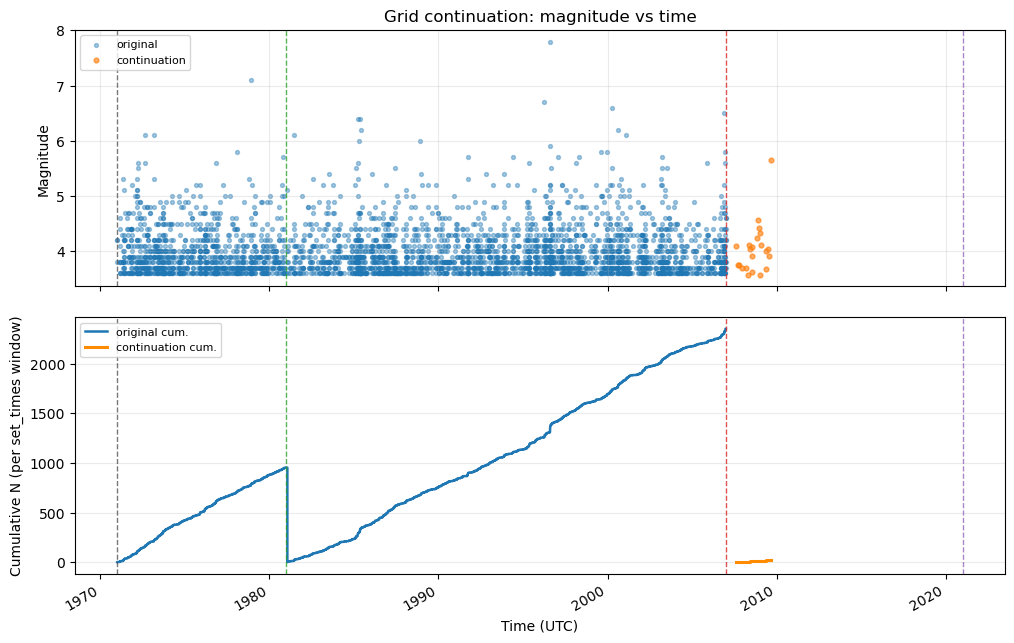

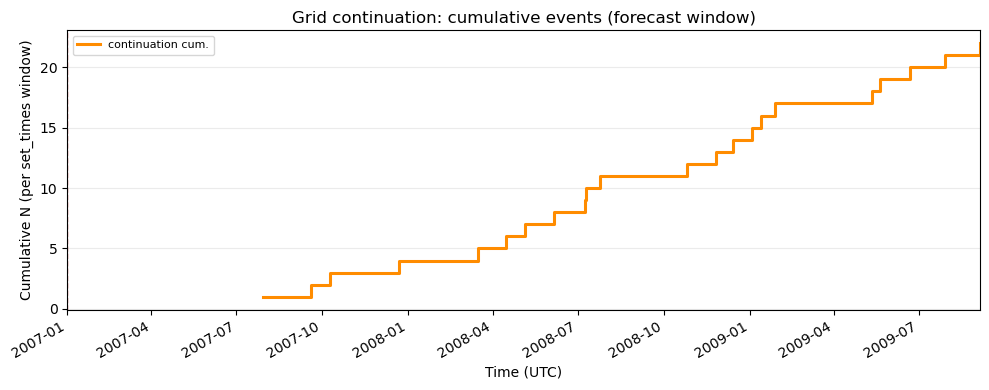

Continuation Δt: n_events=22, median=30.865 d, 5–95%=8.866–93.726 d


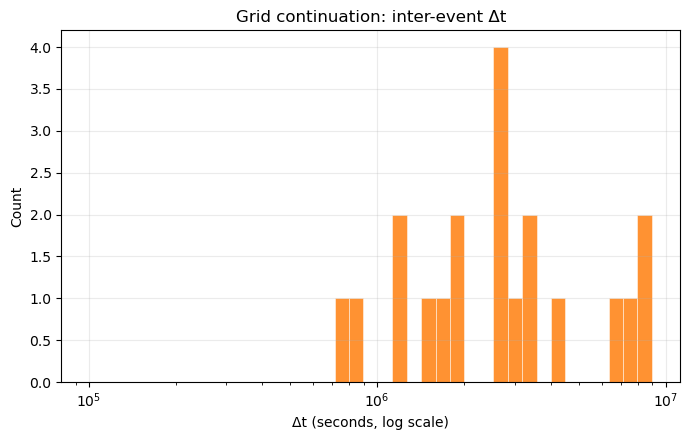

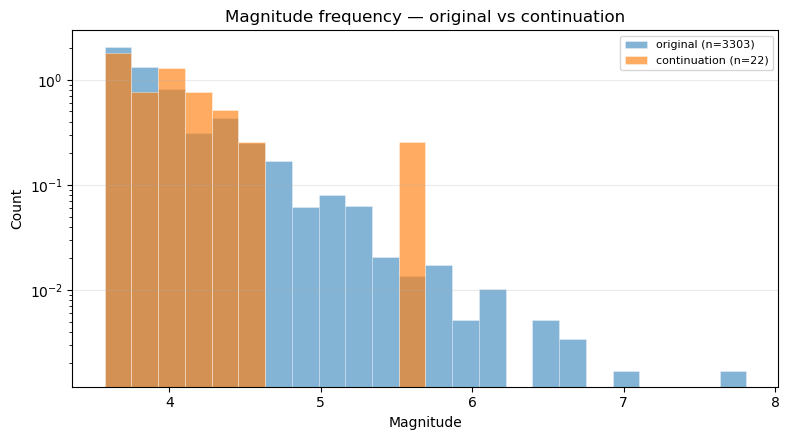

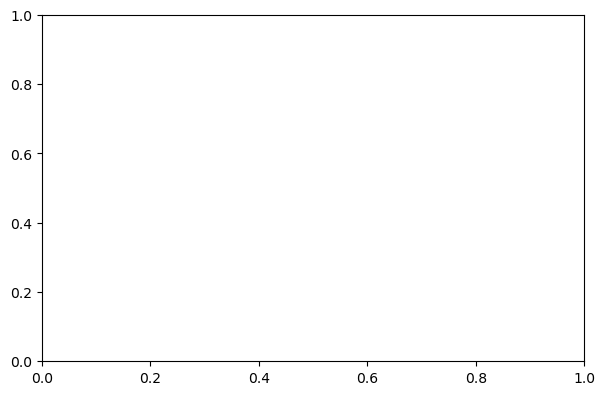

In [42]:
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("matplotlib.font_manager").setLevel(logging.WARNING)

SET_TIME_KEYS = (
    ("auxiliary_start", "#555555"),
    ("timewindow_start", "#2ca02c"),
    ("timewindow_end", "#d62728"),
    ("testwindow_end", "#9467bd"),
)

SET_TIMES = {
    "auxiliary_start": AUXILIARY_START,
    "timewindow_start": TIMEWINDOW_START,
    "timewindow_end": TIMEWINDOW_END,
    "testwindow_end": TESTWINDOW_END,
}


def set_times_and_resets(set_times_dict):
    reset_ts = []
    for key, _ in SET_TIME_KEYS:
        raw = set_times_dict.get(key)
        if raw is None or raw == "":
            continue
        reset_ts.append(pd.to_datetime(raw, utc=True))
    return set_times_dict, sorted(set(reset_ts))


def _cumulative_reset_at_times(sorted_times, reset_ts):
    if not reset_ts:
        return np.arange(1, len(sorted_times) + 1, dtype=np.int64)
    out = np.zeros(len(sorted_times), dtype=np.int64)
    ri = 0
    cnt = 0
    for k in range(len(sorted_times)):
        tt = sorted_times.iloc[k]
        while ri < len(reset_ts) and tt >= reset_ts[ri]:
            cnt = 0
            ri += 1
        cnt += 1
        out[k] = cnt
    return out


def add_set_time_vlines(ax, set_times):
    if not set_times:
        return
    for key, color in SET_TIME_KEYS:
        raw = set_times.get(key)
        if raw is None or raw == "":
            continue
        ts = pd.to_datetime(raw, utc=True)
        ax.axvline(ts, color=color, linestyle="--", linewidth=1.0, alpha=0.8, label=key)


def interevent_seconds(df_cont):
    t = df_cont.sort_values("time")["time"]
    return t.diff().dt.total_seconds().iloc[1:].to_numpy(dtype=float)


st, reset_ts = set_times_and_resets(SET_TIMES)
t_forecast_start = pd.to_datetime(TIMEWINDOW_END, utc=True)

df_original = auxiliary_catalog.copy()
df_original["time"] = pd.to_datetime(df_original["time"], utc=True)
df_original["magnitude"] = pd.to_numeric(df_original["magnitude"], errors="coerce")

df_continuation = simulated.copy()
if len(df_continuation):
    df_continuation["time"] = pd.to_datetime(df_continuation["time"], utc=True)
    df_continuation["magnitude"] = pd.to_numeric(df_continuation["magnitude"], errors="coerce")

df_original_s = df_original.sort_values("time").reset_index(drop=True)
df_continuation_s = df_continuation.sort_values("time").reset_index(drop=True) if len(df_continuation) else df_continuation

print(
    f"Catalog rows — original: {len(df_original)}, continuation (forecast): {len(df_continuation)}"
)

# --- magnitude vs time + cumulative (original blue, continuation orange) ---
fig, (ax_mag, ax_cum) = plt.subplots(2, 1, figsize=(12, 8), sharex=True, gridspec_kw={"hspace": 0.12})

ax_mag.scatter(df_original["time"], df_original["magnitude"], s=8, alpha=0.4, c="tab:blue", label="original")
if len(df_continuation):
    ax_mag.scatter(
        df_continuation["time"],
        df_continuation["magnitude"],
        s=12,
        alpha=0.65,
        c="tab:orange",
        label="continuation",
    )
ax_mag.set_ylabel("Magnitude")
ax_mag.set_title("Grid continuation: magnitude vs time")
ax_mag.legend(loc="upper left", fontsize=8)
ax_mag.grid(True, alpha=0.25)
add_set_time_vlines(ax_mag, st)

ax_cum.plot(
    df_original_s["time"],
    _cumulative_reset_at_times(df_original_s["time"], reset_ts),
    color="tab:blue",
    lw=1.8,
    drawstyle="steps-post",
    label="original cum.",
)
if len(df_continuation_s):
    ax_cum.plot(
        df_continuation_s["time"],
        _cumulative_reset_at_times(df_continuation_s["time"], reset_ts),
        color="darkorange",
        lw=2.2,
        drawstyle="steps-post",
        label="continuation cum.",
    )
ax_cum.set_ylabel("Cumulative N (per set_times window)")
ax_cum.set_xlabel("Time (UTC)")
ax_cum.legend(loc="upper left", fontsize=8)
ax_cum.grid(True, axis="y", alpha=0.25)
add_set_time_vlines(ax_cum, st)

fig.autofmt_xdate()
fig.tight_layout()
display(fig)
plt.close(fig)

# --- continuation cumulative only (zoomed to forecast window) ---
fig_cont, ax_cont = plt.subplots(figsize=(10, 4))
if len(df_continuation_s):
    ax_cont.plot(
        df_continuation_s["time"],
        _cumulative_reset_at_times(df_continuation_s["time"], reset_ts),
        color="darkorange",
        lw=2.2,
        drawstyle="steps-post",
        label="continuation cum.",
    )
    ax_cont.set_xlim(t_forecast_start, df_continuation_s["time"].max())
ax_cont.set_ylabel("Cumulative N (per set_times window)")
ax_cont.set_xlabel("Time (UTC)")
ax_cont.set_title("Grid continuation: cumulative events (forecast window)")
ax_cont.legend(loc="upper left", fontsize=8)
ax_cont.grid(True, axis="y", alpha=0.25)
add_set_time_vlines(ax_cont, st)
fig_cont.autofmt_xdate()
fig_cont.tight_layout()
display(fig_cont)
plt.close(fig_cont)

# --- inter-event Δt (continuation only) ---
dt_cont = interevent_seconds(df_continuation) if len(df_continuation) else np.array([], dtype=float)
if len(dt_cont):
    q = np.quantile(dt_cont, [0.05, 0.5, 0.95])
    print(
        f"Continuation Δt: n_events={len(dt_cont) + 1}, "
        f"median={q[1] / 86400:.3f} d, 5–95%={q[0] / 86400:.3f}–{q[2] / 86400:.3f} d"
    )
else:
    print("Continuation Δt: no inter-event gaps (≤1 event)")

fig_dt, ax_dt = plt.subplots(figsize=(7, 4.5))
if len(dt_cont):
    dt_pos = dt_cont[dt_cont > 0]
    if len(dt_pos):
        dt_lo = max(1.0, float(dt_pos.min()))
        dt_hi = max(dt_lo * 1.01, float(dt_pos.max()))
        bins_dt = np.logspace(np.log10(dt_lo), np.log10(dt_hi), 40)
        ax_dt.hist(dt_pos, bins=bins_dt, color="tab:orange", alpha=0.85, edgecolor="white", linewidth=0.4)
        ax_dt.set_xscale("log")
ax_dt.set_xlabel("Δt (seconds, log scale)")
ax_dt.set_ylabel("Count")
ax_dt.set_title("Grid continuation: inter-event Δt")
ax_dt.grid(True, alpha=0.25)
fig_dt.tight_layout()
display(fig_dt)
plt.close(fig_dt)

# --- magnitude frequency (original vs continuation) ---
all_mag = pd.concat([df_original["magnitude"], df_continuation["magnitude"]], ignore_index=True)
mag_lo = float(all_mag.min()) if len(all_mag) else mc
mag_hi = float(all_mag.max()) if len(all_mag) else mc + 2.0
mag_bins = np.linspace(mag_lo, mag_hi + 0.01, 25)

fig_mfd, ax_mfd = plt.subplots(figsize=(8, 4.5))
ax_mfd.hist(
    df_original["magnitude"],
    bins=mag_bins,
    alpha=0.55,
    color="tab:blue",
    label=f"original (n={len(df_original)})",
    edgecolor="white",
    linewidth=0.4,
    density=True,
)
if len(df_continuation):
    ax_mfd.hist(
        df_continuation["magnitude"],
        bins=mag_bins,
        alpha=0.65,
        color="tab:orange",
        label=f"continuation (n={len(df_continuation)})",
        edgecolor="white",
        linewidth=0.4,
        density=True,
    )
ax_mfd.set_xlabel("Magnitude")
ax_mfd.set_ylabel("Count")
ax_mfd.set_title("Magnitude frequency — original vs continuation")
ax_mfd.legend(loc="upper right", fontsize=8)
ax_mfd.set_yscale("log")
ax_mfd.grid(True, axis="y", alpha=0.25)
fig_mfd.tight_layout()
display(fig_mfd)
plt.close(fig_mfd)


## Step 6 — Quick spatial check

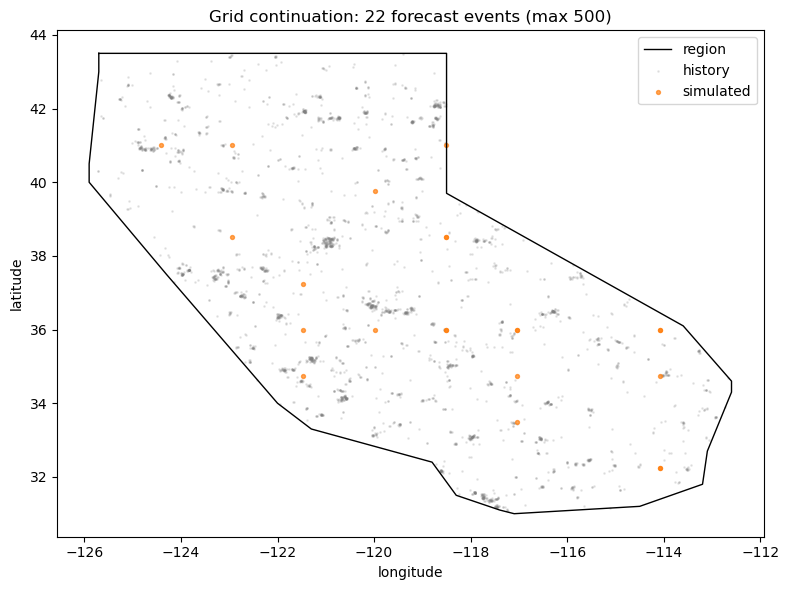

In [43]:
# Inversion sets root logging to DEBUG; suppress matplotlib font spam in this cell.
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("matplotlib.font_manager").setLevel(logging.WARNING)

fig, ax = plt.subplots(figsize=(8, 6))
poly_x, poly_y = zip(*[(p[1], p[0]) for p in polygon.exterior.coords])  # lon, lat for plot
ax.plot(poly_x, poly_y, "k-", lw=1, label="region")
hist = auxiliary_catalog[auxiliary_catalog["time"] < forecast_start]
ax.scatter(hist["longitude"], hist["latitude"], s=1, alpha=0.15, c="gray", label="history")
if len(simulated):
    ax.scatter(simulated["longitude"], simulated["latitude"], s=8, alpha=0.7, c="C1", label="simulated")
ax.set_xlabel("longitude")
ax.set_ylabel("latitude")
ax.legend(loc="upper right")
ax.set_title(f"Grid continuation: {len(simulated)} forecast events (max {MAX_FORECAST_EVENTS})")
fig.tight_layout()
display(fig)
plt.close(fig)
